In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.decomposition import PCA
import matplotlib.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import f
import pickle
import seaborn as sns
from sklearn.metrics import *

# Load the data

In [3]:
data = pd.read_csv(r'M:\ML_scripts\github_files\tm60-full-compiled-data.csv').drop(columns=['Unnamed: 0'])

train = data[data['Set'] == 'train']
test = data[data['Set'] == 'test']

train_smi = train['Structure']
test_smi = test['Structure']

train_clf = train['Class']
test_clf = test['Class']

# Load model descriptor

In [4]:
with open(r'M:\ML_scripts\github_files\tm60.pkl', 'rb') as file:
    model = pickle.load(file)

predictor = model.predictor
descriptor = model.descriptor

# Generate descriptors

In [5]:
train_fp = []
test_fp = []

for x in train_smi:
    desc = descriptor.calculate_from_smi(x)
    train_fp.append((desc))

for x in test_smi:
    desc = descriptor.calculate_from_smi(x)
    test_fp.append((desc))

 # Fit the PCA (ECFP_counts)

In [6]:
pca = PCA(n_components=2)

train_pca = pca.fit_transform(train_fp)
test_pca = pca.transform(test_fp)

# Finding the AD

In [7]:
eigenvalues = pca.explained_variance_

T2_train = np.sum((train_pca ** 2) / eigenvalues, axis=1)

n = len(train_fp)
p = 2
alpha = 0.01

F_val = f.ppf(1 - alpha, p, n - p)
T2_threshold = (p * (n-1) * F_val) / (n - p)

print(f'Threshold at 95% confidence level: {T2_threshold:.4f}')

T2_test = np.sum((test_pca ** 2) / eigenvalues, axis=1)

t2_values = []

for i, t2 in enumerate(T2_test):
    if t2 <= T2_threshold:
        print(f'Test point {i} is inside the AD space with T2 value: {t2:.4f}')
    else:
        print(f'Test point {i} is outside the AD space with T2 value: {t2:.4f}')
        
    t2_values.append(t2)

Threshold at 95% confidence level: 9.3099
Test point 0 is inside the AD space with T2 value: 4.1013
Test point 1 is inside the AD space with T2 value: 2.5018
Test point 2 is inside the AD space with T2 value: 1.5737
Test point 3 is inside the AD space with T2 value: 4.0976
Test point 4 is inside the AD space with T2 value: 1.3386
Test point 5 is inside the AD space with T2 value: 0.9673
Test point 6 is inside the AD space with T2 value: 2.0650
Test point 7 is inside the AD space with T2 value: 4.0547
Test point 8 is inside the AD space with T2 value: 0.8107
Test point 9 is inside the AD space with T2 value: 2.4349
Test point 10 is inside the AD space with T2 value: 0.9986
Test point 11 is inside the AD space with T2 value: 2.3857
Test point 12 is inside the AD space with T2 value: 2.2195
Test point 13 is inside the AD space with T2 value: 2.9233
Test point 14 is inside the AD space with T2 value: 1.8162
Test point 15 is inside the AD space with T2 value: 0.9160
Test point 16 is inside 

# Plotting the AD

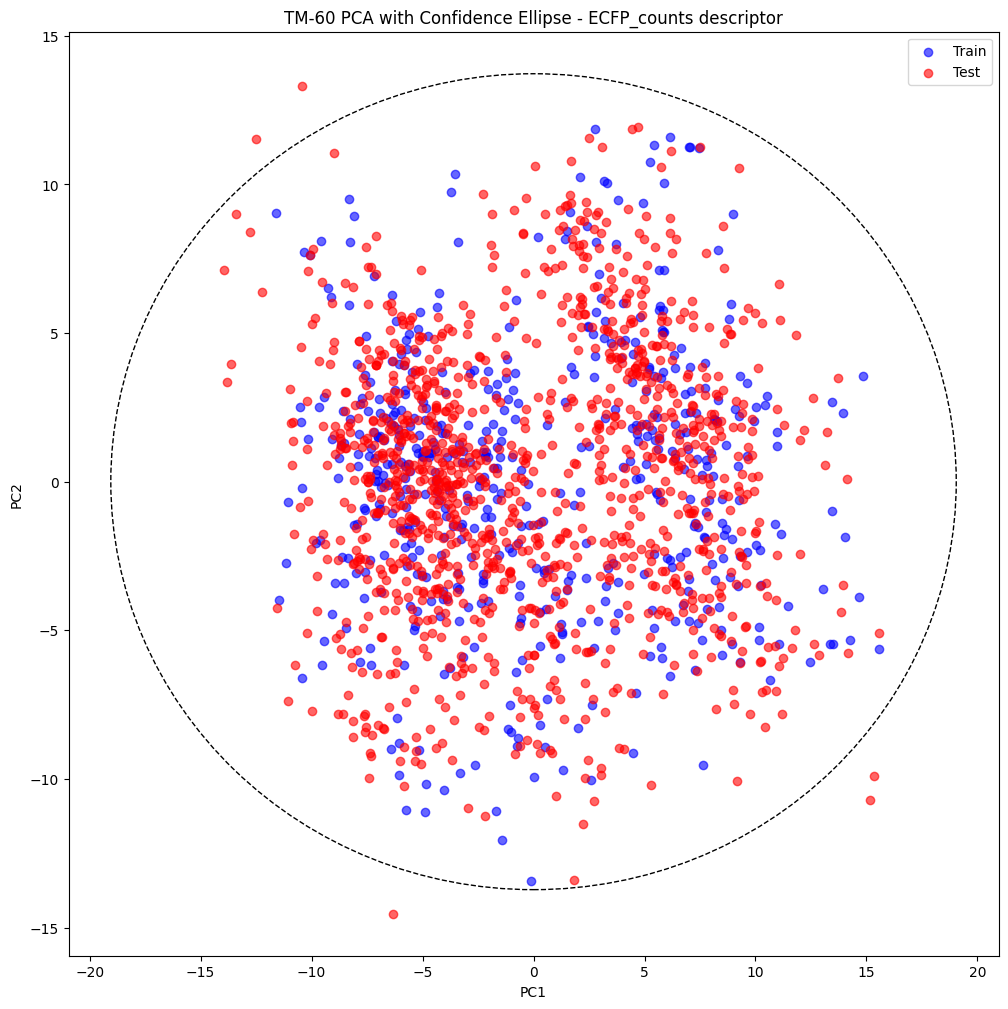

In [ ]:
plt.figure(figsize=(12, 12))

plt.scatter(train_pca[:, 0], train_pca[:, 1], label='Train', alpha=0.6, color='blue')
plt.scatter(test_pca[:, 0], test_pca[:, 1], label='Test', alpha=0.6, color='red')


def plot_confidence_ellipse(mean, cov, ax, threshold, **kwargs):

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 2 * np.sqrt(vals * threshold)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellipse)

ax = plt.gca()
mean = np.mean(train_pca[:, :2], axis=0)
cov = np.cov(train_pca[:, :2].T)

plot_confidence_ellipse(mean, cov, ax, T2_threshold, edgecolor='black', facecolor='none', linestyle='--')

plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('TM-60 PCA with Confidence Ellipse - ECFP_counts descriptor')
plt.show()

# Removing outliers

In [9]:
rows = [397, 450, 1076, 1117, 1158]

ad_test = test.reset_index(drop=True)

ad_test = ad_test.drop(index=rows)

# Model performance on 'domained' data (no train outside the AD so only need to see the affect on testing performance)

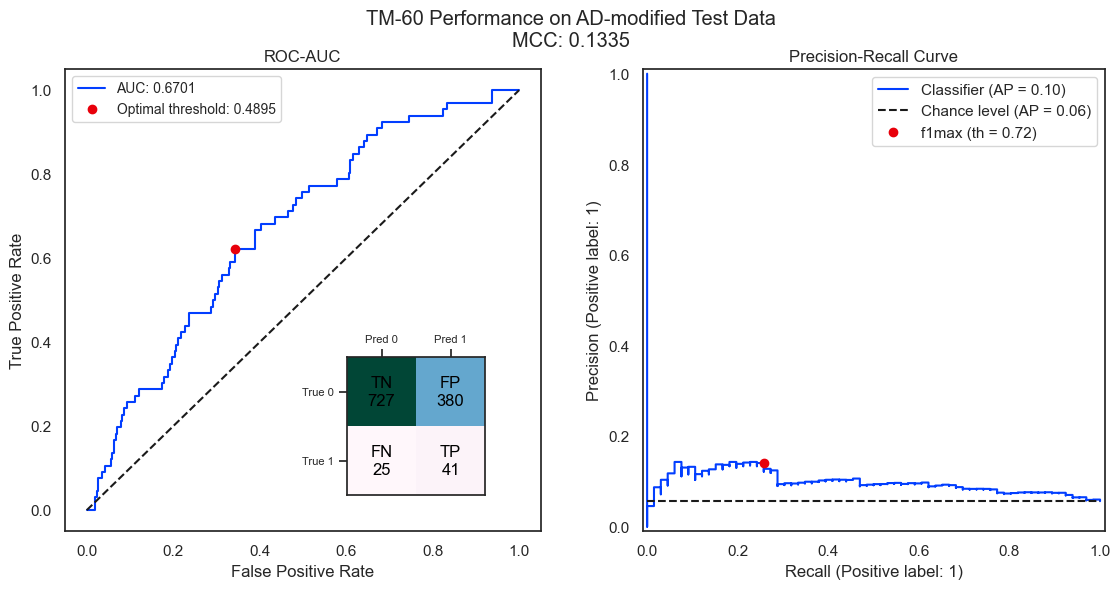

In [10]:
y_true = ad_test['Class']
y_pred = model.predict_from_smiles(ad_test['Structure'])

sns.set_theme(style="white", palette='bright')

fig, axs = plt.subplots(1,2, figsize=(13.5, 6))                                     
x = np.linspace(0,1)                     
                             
plt.subplot(121)

## Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred)           
auc = np.trapz(tpr, fpr) 
                                          
plt.plot(fpr, tpr)                                               
axs[0].set_title('ROC-AUC')

## Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

## Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"TM-60 Performance on AD-modified Test Data\nMCC: {mcc:.4}")           
                         

cm = confusion_matrix(y_true, y_pred_bin)                                 

tn, fp, fn, tp = cm.ravel()
values = np.array([[tn,fp], [fn,tp]])
labels = np.array([['TN','FP'],['FN','TP']])

# Plotting the Precision-Recall curve

pos_label = 1 
precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)    
f1_scores = 2 * recall * precision / (recall + precision)                                       
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# confusion matrix on inset axes

inset_ax = fig.add_axes([0.27,0.17,0.23,0.23])
inset_ax.matshow(values, cmap=plt.cm.PuBuGn)

inset_ax.set_xticks([0, 1])
inset_ax.set_yticks([0, 1])

inset_ax.xaxis.set_ticks_position('top')
inset_ax.yaxis.set_ticks_position('left')

inset_ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
inset_ax.set_yticklabels(['True 0', 'True 1'], fontsize=8)

# Add custom TN, FP, FN, TP labels + counts

for (i, j), val in np.ndenumerate(values):
    text = f"{labels[i, j]}\n{val}"
    inset_ax.text(j, i, text, ha='center', va='center', fontsize=12, color='black')

plt.show()

# 'New' AD

Text(0.5, 1.0, 'TM-60 PCA with AD Test Data - ECFP_counts descriptor, defined AD space')

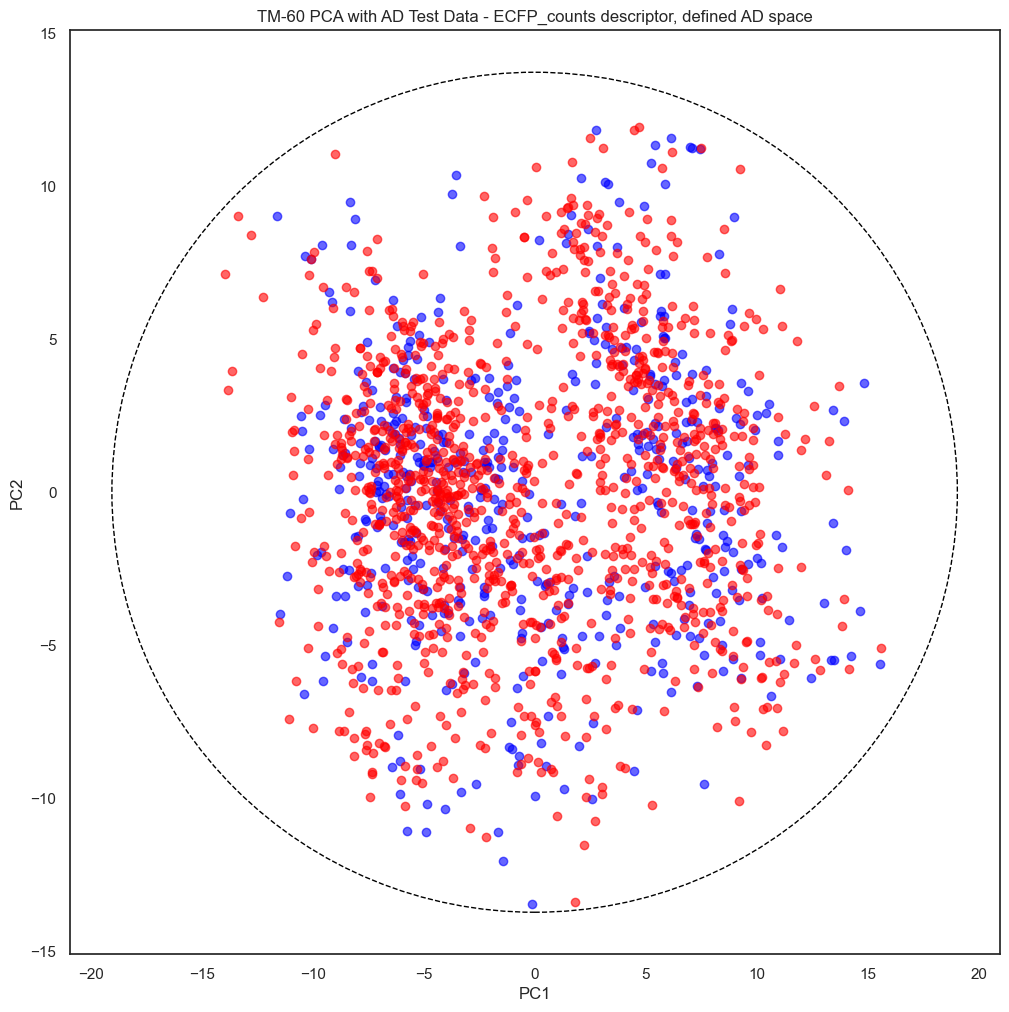

In [19]:
plt.figure(figsize=(12, 12))

plt.scatter(train_pca[:, 0], train_pca[:, 1], label='Train', alpha=0.6, color='blue')

ad_test_fp = []

for x in ad_test['Structure']:
    desc = descriptor.calculate_from_smi(x)
    ad_test_fp.append((desc))

ad_test_pca = pca.transform(ad_test_fp)

plt.scatter(ad_test_pca[:, 0], ad_test_pca[:, 1], label='AD Test', alpha=0.6, color='red')

ax = plt.gca()
mean = np.mean(train_pca[:, :2], axis=0)
cov = np.cov(train_pca[:, :2].T)

plot_confidence_ellipse(mean, cov, ax, T2_threshold, edgecolor='black', facecolor='none', linestyle='--')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('TM-60 PCA with AD Test Data - ECFP_counts descriptor, defined AD space')